<a href="https://colab.research.google.com/github/Sebacaraballo/ME239---Data-Science-for-ME/blob/main/lecture13/homework_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(lecture13:homework)=
# Homework 13

+ Type your name and email in the "Student details" section below.
+ Develop the code and generate the figures you need to solve the problems using this notebook.
+ For the answers that require a mathematical proof or derivation you can either:
    
    - Type the answer using the built-in latex capabilities. In this case, simply export the notebook as a pdf and upload it on gradescope; or
    - You can print the notebook (after you are done with all the code), write your answers by hand, scan, turn your response to a single pdf, and upload on gradescope.

+ The total homework points are 100. Please note that the problems are not weighed equally.

```{note}
+ Please match all the pages corresponding to each of the questions when you submit on gradescope.
```

## Student details

+ **First Name:** Sebastian
+ **Last Name:** Caraballo
+ **Email:** scarabal@purdue.edu

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(rc={"figure.dpi":100, 'savefig.dpi':300})
sns.set_context('notebook')
sns.set_style("ticks")
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina', 'svg')
import numpy as np
import scipy.stats as st

/tmp/ipykernel_7595/122018214.py:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina', 'svg')


## Problem 1 - Maximum likelihood estimate of an Exponential random variable

You are managing toll station and your job is to come up with a probabilistic model for the time that passes between car arrivals.
You have at your disposal data:

$$
T_{1:N} = (t_1, t_2, \dots, t_N).
$$

Here $t_1$ is the time that passed until the first event, $t_2$ is the time that passed from the first event to the second, and so on.
You decide to model these random time intervals using an Exponential distribution with uknown rate parameter $\lambda$, i.e.,

$$
T_i | \lambda \sim \text{Exponential}(\lambda).
$$

In terms of the PDF:

$$
p(t_i | \lambda) = \lambda e^{-\lambda t_i}.
$$

You have decided to use maximum likelihood to fit the parameter $\lambda$.
Answer the following questions:

+ Find the mathematical form of the likelihood of the data $p(t_{1:N}|\lambda)$.

**Answer:**
<br><br>Since the observations are i.i.d.:
p(t₁:N|λ) = ∏ᵢ₌₁ᴺ λe^(-λtᵢ) = λᴺ e^(-λ∑tᵢ)

+ Find the mathematical form of the log-likelihood $J(\lambda) = \log p(t_{1:N}|\lambda)$.

**Answer:**
<br><br>J(λ) = log p(t₁:N|λ) = N·log(λ) - λ∑ᵢtᵢ

+ Take the derivative $\frac{dJ(\lambda)}{d\lambda}$ of $J(\lambda)$ with respect to $\lambda$.

**Answer:**
<br><br>dJ/dλ = N/λ - ∑ᵢtᵢ

+ Find the MLE $\hat{\lambda}$ by solving the equation $\frac{dJ(\lambda)}{d\lambda} = 0$ for $\lambda$.

**Answer:**
<br><br>N/λ - ∑ᵢtᵢ = 0 → λ̂ = N / ∑ᵢtᵢ = 1/t̄
The MLE is simply the inverse of the sample mean.

## Problem 2 - Failure of a mechanical component

Assume that you designing a gear for a mechanical system.
Under normal operating conditions the gear is expected to fail at a random time.
Let $T$ be a random variable capturing the time the gear fails.
What should the probability density of $T$ look like?
Well, when the gear is brand new, the probability density should be close to zero because a new gear does not fail under normal opearating conditions.
As time goes by, the probability density should increase because various things start happening to the material, e.g., crack formation, fatigue, etc.
Finally, the probability density must again start going to zero as time further increases because nothing lasts forever...
A probability distribution that is commonly used to model this situation is the [Weibull](https://en.wikipedia.org/wiki/Weibull_distribution).
We are going to fit some fail time data to a Weibull distribution and then you will have to answer a few questions about failing times.

In [2]:
# Time to fail in years under normal operating conditions
# Each row is a different gear
time_to_fail_data = np.array([
    10.5,
    7.5,
    8.1,
    8.4,
    11.2,
    9.3,
    8.9,
    12.4
])

Here is a Weibull distribution fitted to the data using maximum likelihood:

In [3]:
fitted_params = st.exponweib.fit(time_to_fail_data, loc=0)
T = st.exponweib(*fitted_params)

Let's plot the probability density of this:

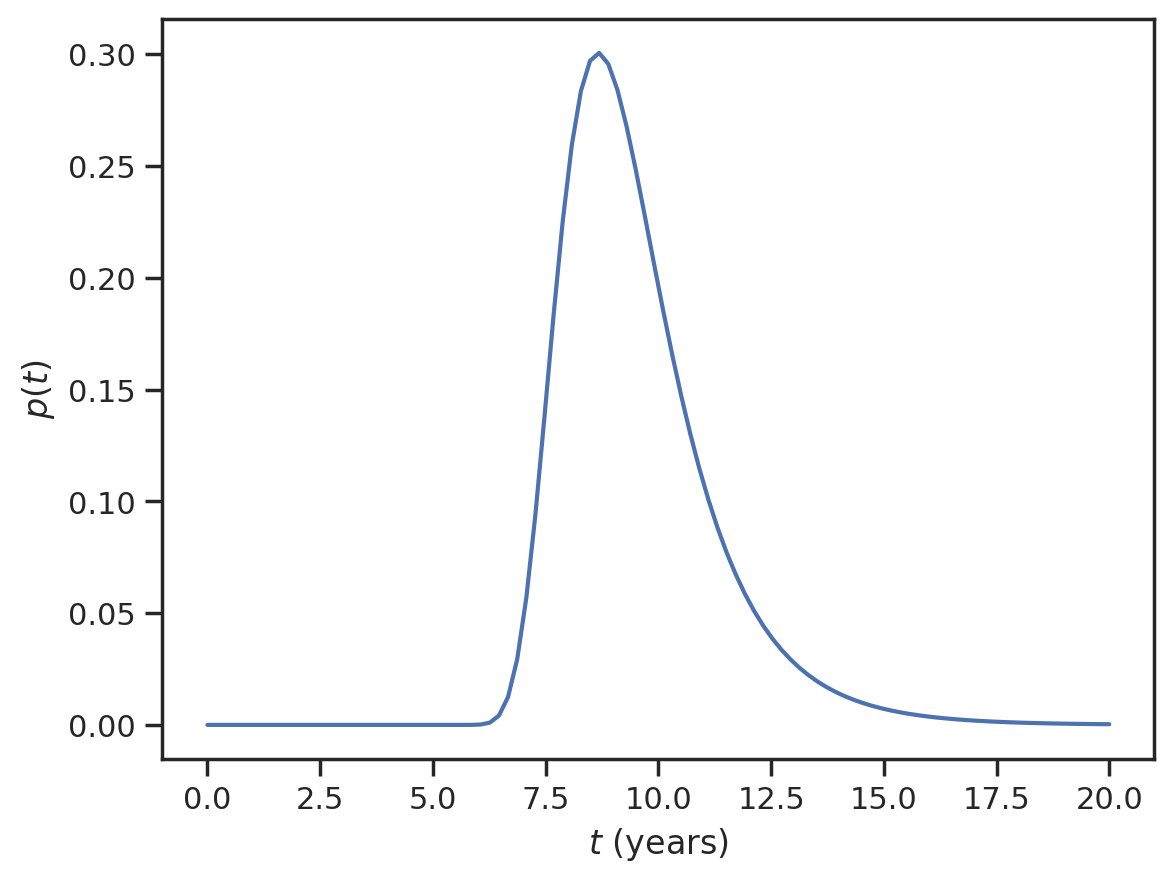

In [4]:
fig, ax = plt.subplots(dpi=100)
ts = np.linspace(0.0, 20.0, 100)
ax.plot(ts, T.pdf(ts))
ax.set_xlabel('$t$ (years)')
ax.set_ylabel('$p(t)$');

+ Find the mean fail time and its variance.
Hint: Do not integrate anything by hand. Just use the functionality of ``scipy.stats``.

In [5]:
t_mean = T.mean()
t_var = T.var()
print(f'E[T] = {t_mean:1.2f}')
print(f'V[T] = {t_var:1.2f}')

E[T] = 9.53
V[T] = 2.88


+ Plot the cumulative distribution function of $T$.

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_7595/3939730156.py:5: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('$F(t) = P(T \leq t)$')


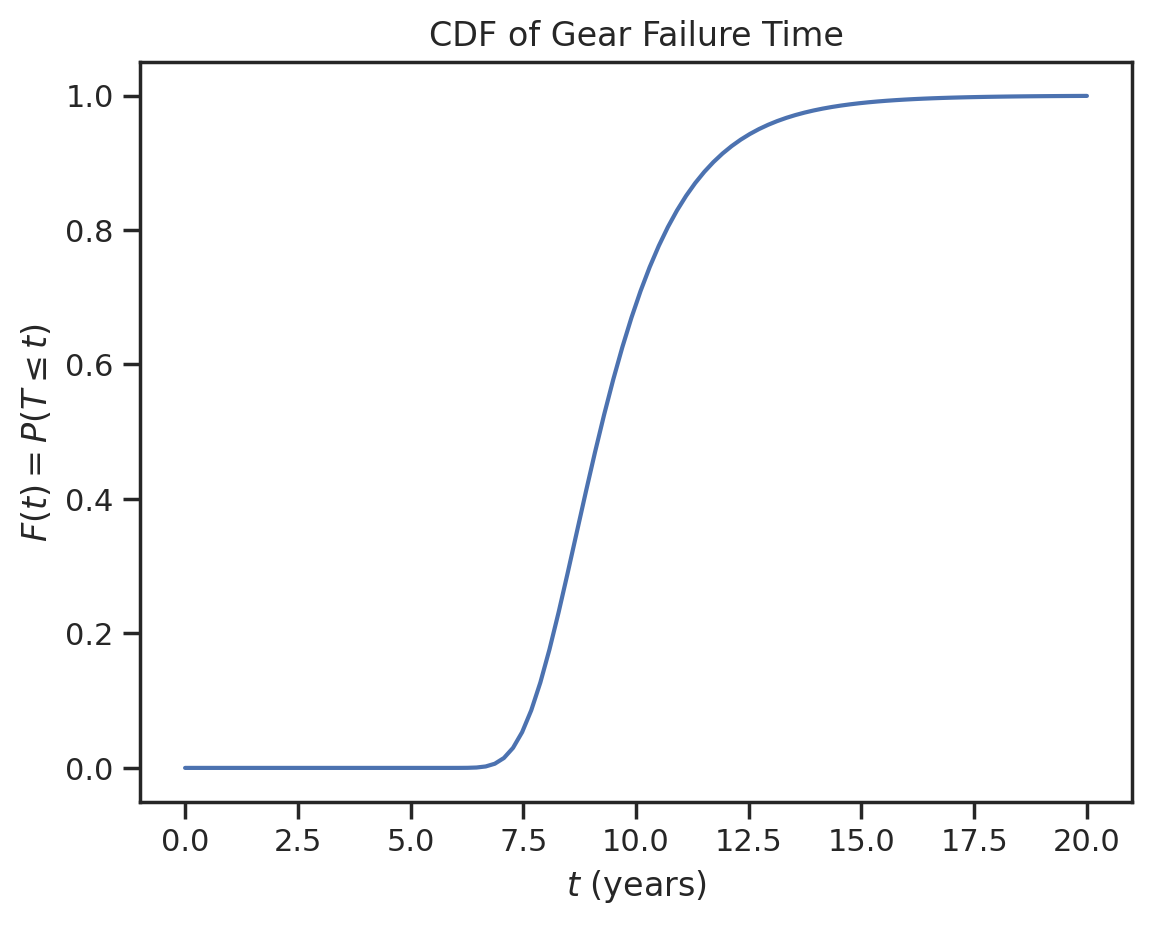

In [6]:
ts = np.linspace(0.0, 20.0, 100)
fig, ax = plt.subplots(dpi=100)
ax.plot(ts, T.cdf(ts))
ax.set_xlabel('$t$ (years)')
ax.set_ylabel('$F(t) = P(T \leq t)$')
ax.set_title('CDF of Gear Failure Time');

+ Plot the probability that gear survives for more than $t$ as a function of $t$.
That is, plot the function:

$$
S(t) = p(T > t).
$$

Hint: First express this function in terms of the cumulative distribution function of $T$.

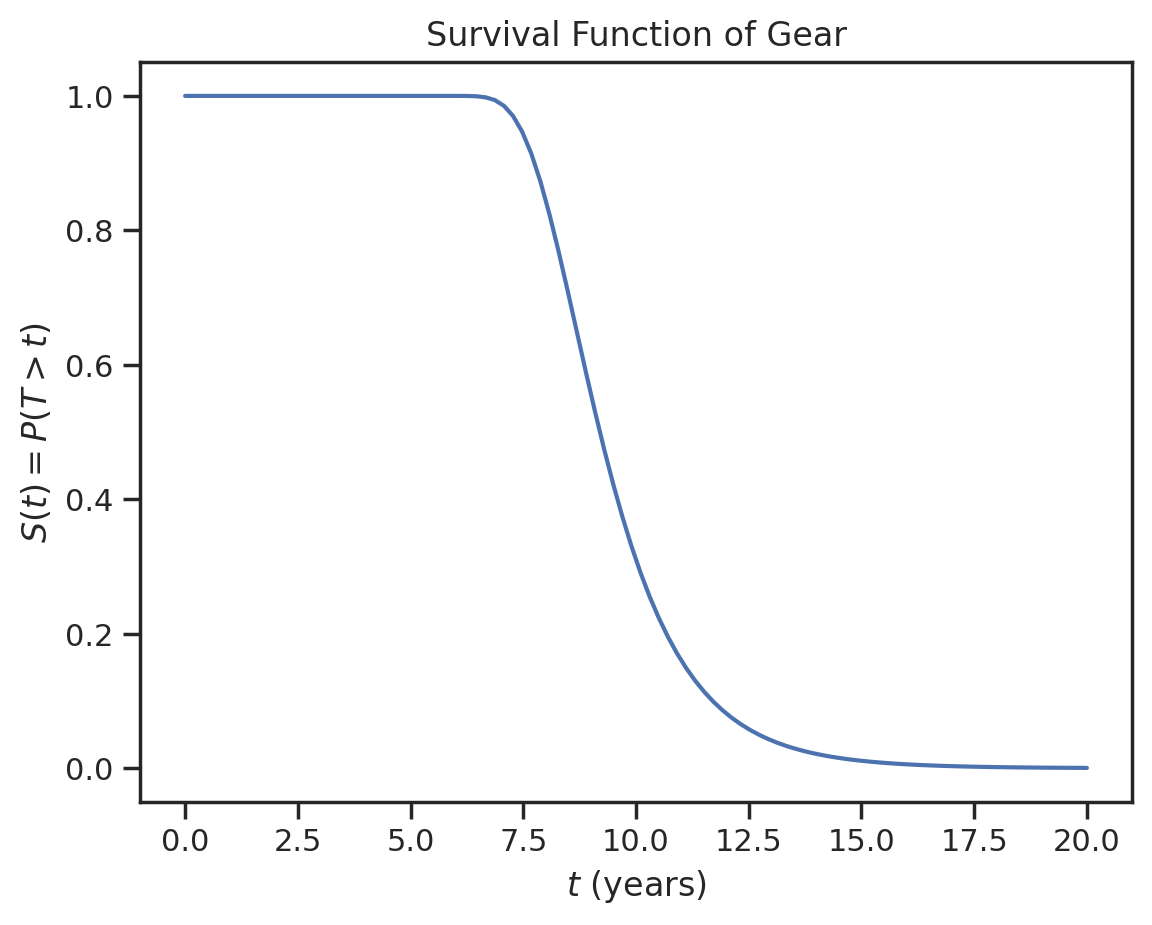

In [7]:
fig, ax = plt.subplots(dpi=100)
ax.plot(ts, 1 - T.cdf(ts))
ax.set_xlabel('$t$ (years)')
ax.set_ylabel('$S(t) = P(T > t)$')
ax.set_title('Survival Function of Gear');

+ Find the probability that the gear lasts anywhere between 8 and 10 years.

In [8]:
p_8_to_10 = T.cdf(10) - T.cdf(8)
print(f'P(8 <= T <= 10) = {p_8_to_10:.4f}')

P(8 <= T <= 10) = 0.5343


+ If you were to sell the gear, how many years "warranty" would you offer and why?

**Answer:**


In [9]:
# Find the time at which 90% of gears are still surviving (10th percentile of failure)
warranty = T.ppf(0.10)
print(f'Suggested warranty: {warranty:.2f} years')

Suggested warranty: 7.75 years


Run the following code to convert the notebook to a pdf. Verify that the file path to the notebook is correct.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!apt-get install inkscape texlive texlive-xetex texlive-latex-extra pandoc --quiet
!pip install pypandoc --quiet
!jupyter nbconvert --to PDF '/content/drive/MyDrive/Colab Notebooks/Copy of homework_13.ipynb'